In [ ]:
import pandas as pd

# Load your CSV
df = pd.read_csv("final.csv")
df = df.drop(columns=['_id_x', '_id_y'])
# Convert datetime column
df['datetime'] = pd.to_datetime(df['datetime'])

# Filter only year 2025
df_2025 = df[
    (df['datetime'] >= '2025-01-01') &
    (df['datetime'] < '2026-01-01')
]

# Save to new CSV file
df_2025.to_csv("2025_load.csv", index=False)

print("Saved successfully as 2025_load.csv")

Saved successfully as 2025_load.csv


2025 equations and 2026 winter prediction

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Function to train and print equation
def run_regression(file_name, season_name):
    df = pd.read_csv(file_name)

    # Features and target
    X = df[['temp', 'rh']]
    y = df['wdLoad']

    # Model
    model = LinearRegression()
    model.fit(X, y)

    # Coefficients
    intercept = model.intercept_
    coef_temp = model.coef_[0]
    coef_rh = model.coef_[1]

    print(f"\n--- {season_name} ---")
    print(f"Equation:")
    print(f"wdLoad = {intercept:.4f} + ({coef_temp:.4f} * temp) + ({coef_rh:.4f} * rh)")

    return model

# Run for each season
winter_model = run_regression("winter_2025.csv", "Winter")
summer_model = run_regression("summer_2025.csv", "Summer")
monsoon_model = run_regression("monsoon_2025.csv", "Monsoon")
autumn_model = run_regression("autumn_2025.csv", "Autumn")


--- Winter ---
Equation:
wdLoad = -117.8124 + (18.7679 * temp) + (-0.1326 * rh)

--- Summer ---
Equation:
wdLoad = -436.0413 + (27.9236 * temp) + (0.4927 * rh)

--- Monsoon ---
Equation:
wdLoad = -205.0712 + (25.1965 * temp) + (-0.6180 * rh)

--- Autumn ---
Equation:
wdLoad = -122.3786 + (19.2465 * temp) + (0.2856 * rh)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the winter_2026.csv file
df_winter_2026 = pd.read_csv("winter_2026.csv")

# Coefficients from the winter equation derived earlier (from cell czIO5NAoXPP2 or cAP8kozcXy7v)
# wdLoad = -117.8124 + (18.7679 * temp) + (-0.1326 * rh)
intercept = -117.8124
coef_temp = 18.7679
coef_rh = -0.1326

# Predict wdLoad using the winter equation
df_winter_2026['predicted_wdLoad'] = intercept + \
                                     (coef_temp * df_winter_2026['temp']) + \
                                     (coef_rh * df_winter_2026['rh'])

# Actual wdLoad values
y_true = df_winter_2026['wdLoad']

# Predicted wdLoad values
y_pred = df_winter_2026['predicted_wdLoad']

# Calculate evaluation metrics

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_true, y_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_true, y_pred)

print("\n--- Model Performance for Winter 2026 using Winter 2025 Equation ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

# Display the first few rows with actual and predicted values
print("\nActual vs. Predicted wdLoad (first 5 rows):")
display(df_winter_2026[['datetime', 'wdLoad', 'predicted_wdLoad']].head())


--- Model Performance for Winter 2026 using Winter 2025 Equation ---
Mean Absolute Error (MAE): 63.8963
Root Mean Squared Error (RMSE): 77.8376
Mean Absolute Percentage Error (MAPE): 14.8982%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2025-12-01 00:00:00+00:00,298.534462,272.608830
1,2025-12-01 00:15:00+00:00,304.524118,271.630655
2,2025-12-01 00:30:00+00:00,319.374861,270.785080
3,2025-12-01 00:45:00+00:00,329.508837,271.962155
4,2025-12-01 01:00:00+00:00,343.143157,271.116580


In [ ]:
import pandas as pd
import numpy as np

def manual_mlr(file_name, season_name):
    df = pd.read_csv(file_name)

    # Extract variables
    temp = df['temp'].values
    rh = df['rh'].values
    y = df['wdLoad'].values

    n = len(df)

    # Construct X matrix: [1, temp, rh]
    X = np.column_stack((np.ones(n), temp, rh))

    # Apply formula: β = (XᵀX)^(-1) Xᵀy
    Xt = X.T
    beta = np.linalg.inv(Xt @ X) @ Xt @ y

    b0, b1, b2 = beta

    print(f"\n--- {season_name} ---")
    print(f"wdLoad = {b0:.4f} + ({b1:.4f})·temp + ({b2:.4f})·rh")

# Run for all seasons
manual_mlr("winter_2025.csv", "Winter")
manual_mlr("summer_2025.csv", "Summer")
manual_mlr("monsoon_2025.csv", "Monsoon")
manual_mlr("autumn_2025.csv", "Autumn")


--- Winter ---
wdLoad = -117.8124 + (18.7679)·temp + (-0.1326)·rh

--- Summer ---
wdLoad = -436.0413 + (27.9236)·temp + (0.4927)·rh

--- Monsoon ---
wdLoad = -205.0712 + (25.1965)·temp + (-0.6180)·rh

--- Autumn ---
wdLoad = -122.3786 + (19.2465)·temp + (0.2856)·rh


2024 dataset and perfromce on 2025


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Function to train and print equation
def run_regression(file_name, season_name):
    df = pd.read_csv(file_name)

    # Features and target
    X = df[['temp', 'rh']]
    y = df['wdLoad']

    # Model
    model = LinearRegression()
    model.fit(X, y)

    # Coefficients
    intercept = model.intercept_
    coef_temp = model.coef_[0]
    coef_rh = model.coef_[1]

    print(f"\n--- {season_name} ---")
    print(f"Equation:")
    print(f"wdLoad = {intercept:.4f} + ({coef_temp:.4f} * temp) + ({coef_rh:.4f} * rh)")

    return model

# Run for each season
winter_model_2024 = run_regression("winter_2024.csv", "Winter 2024")
summer_model_2024 = run_regression("summer_2024.csv", "Summer 2024")
monsoon_model_2024 = run_regression("monsoon_2024.csv", "Monsoon 2024")
autumn_model_2024 = run_regression("autumn_2024.csv", "Autumn 2024")


--- Winter 2024 ---
Equation:
wdLoad = -16.7462 + (13.5990 * temp) + (0.0855 * rh)

--- Summer 2024 ---
Equation:
wdLoad = -200.1241 + (20.1902 * temp) + (-0.1081 * rh)

--- Monsoon 2024 ---
Equation:
wdLoad = -358.9728 + (25.8228 * temp) + (0.2584 * rh)

--- Autumn 2024 ---
Equation:
wdLoad = -101.8379 + (18.2572 * temp) + (-0.3393 * rh)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_and_print_metrics_cross_year(file_name_2025, season_name, intercept_2024, coef_temp_2024, coef_rh_2024):
    df_2025 = pd.read_csv(file_name_2025)

    # Predict wdLoad on 2025 data using 2024 equation
    df_2025['predicted_wdLoad'] = intercept_2024 + \
                                     (coef_temp_2024 * df_2025['temp']) + \
                                     (coef_rh_2024 * df_2025['rh'])

    # Actual wdLoad values from 2025 data
    y_true = df_2025['wdLoad']

    # Predicted wdLoad values
    y_pred = df_2025['predicted_wdLoad']

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    def mean_absolute_percentage_error(y_true, y_pred):
        # Avoid division by zero
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"\n--- Model Performance for {season_name} (2025 data using 2024 equation) ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")
    print("\nActual vs. Predicted wdLoad (first 5 rows):")
    display(df_2025[['datetime', 'wdLoad', 'predicted_wdLoad']].head())

# Coefficients from the 2024 regression models (from cell 4694cb1e)

# Winter 2024 equation applied to Winter 2025 data
calculate_and_print_metrics_cross_year("winter_2025.csv", "Winter 2025",
                                    intercept_2024=-16.7462, coef_temp_2024=13.5990, coef_rh_2024=0.0855)

# Summer 2024 equation applied to Summer 2025 data
calculate_and_print_metrics_cross_year("summer_2025.csv", "Summer 2025",
                                    intercept_2024=-200.1241, coef_temp_2024=20.1902, coef_rh_2024=-0.1081)

# Monsoon 2024 equation applied to Monsoon 2025 data
calculate_and_print_metrics_cross_year("monsoon_2025.csv", "Monsoon 2025",
                                    intercept_2024=-358.9728, coef_temp_2024=25.8228, coef_rh_2024=0.2584)

# Autumn 2024 equation applied to Autumn 2025 data
calculate_and_print_metrics_cross_year("autumn_2025.csv", "Autumn 2025",
                                    intercept_2024=-101.8379, coef_temp_2024=18.2572, coef_rh_2024=-0.3393)


--- Model Performance for Winter 2025 (2025 data using 2024 equation) ---
Mean Absolute Error (MAE): 51.2980
Root Mean Squared Error (RMSE): 62.0100
Mean Absolute Percentage Error (MAPE): 12.6578%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2024-12-01 00:00:00+05:30,300.115986,311.184550
1,2024-12-01 00:15:00+05:30,295.972671,308.550250
2,2024-12-01 00:30:00+05:30,291.000907,306.595900
3,2024-12-01 00:45:00+05:30,287.192283,303.978700
4,2024-12-01 01:00:00+05:30,283.226725,304.688575



--- Model Performance for Summer 2025 (2025 data using 2024 equation) ---
Mean Absolute Error (MAE): 59.3710
Root Mean Squared Error (RMSE): 75.8168
Mean Absolute Percentage Error (MAPE): 12.2102%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2025-03-01 00:00:00+05:30,370.814827,364.683990
1,2025-03-01 00:15:00+05:30,366.624682,363.563678
2,2025-03-01 00:30:00+05:30,362.461917,357.130970
3,2025-03-01 00:45:00+05:30,357.780050,353.354460
4,2025-03-01 01:00:00+05:30,352.549802,351.178695



--- Model Performance for Monsoon 2025 (2025 data using 2024 equation) ---
Mean Absolute Error (MAE): 78.7931
Root Mean Squared Error (RMSE): 99.8375
Mean Absolute Percentage Error (MAPE): 16.2874%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2025-06-01 00:00:00+05:30,396.428498,441.17351
1,2025-06-01 00:15:00+05:30,392.549874,432.08428
2,2025-06-01 00:30:00+05:30,386.370941,423.44682
3,2025-06-01 00:45:00+05:30,386.731033,406.07457
4,2025-06-01 01:00:00+05:30,378.853570,405.62926



--- Model Performance for Autumn 2025 (2025 data using 2024 equation) ---
Mean Absolute Error (MAE): 62.5210
Root Mean Squared Error (RMSE): 80.1818
Mean Absolute Percentage Error (MAPE): 13.2134%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2025-10-01 00:00:00+05:30,361.0,307.91599
1,2025-10-01 00:15:00+05:30,356.0,307.00313
2,2025-10-01 00:30:00+05:30,347.0,307.00313
3,2025-10-01 00:45:00+05:30,344.0,307.00313
4,2025-10-01 01:00:00+05:30,337.0,308.82885


File Conversion

In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv("final.csv")
df = df.drop(columns=['_id_x', '_id_y'])
# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df['datetime'] = df['datetime'].dt.tz_convert('Asia/Kolkata')

# Filter required range: Dec 2024 → Nov 2025
df = df[
    (df['datetime'] >= '203-12-01') &
    (df['datetime'] < '2024-12-01')
]

# Extract year and month
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

# ---- Create seasonal subsets ----

# Winter: Dec 2024 + Jan-Feb 2025
winter = df[
    ((df['year'] == 2023) & (df['month'] == 12)) |
    ((df['year'] == 2024) & (df['month'].isin([1, 2])))
]

# Summer: Mar-May 2025
summer = df[
    (df['year'] == 2024) & (df['month'].isin([3, 4, 5]))
]

# Monsoon: Jun-Sep 2025
monsoon = df[
    (df['year'] == 2024) & (df['month'].isin([6, 7, 8, 9]))
]

# Autumn: Oct-Nov 2025
autumn = df[
    (df['year'] == 2024) & (df['month'].isin([10, 11]))
]

# ---- Save separate CSV files ----
winter.to_csv("winter_2024.csv", index=False)
summer.to_csv("summer_2024.csv", index=False)
monsoon.to_csv("monsoon_2024.csv", index=False)
autumn.to_csv("autumn_2024.csv", index=False)

print("All seasonal CSV files saved successfully!")

All seasonal CSV files saved successfully!


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv("final.csv")
df = df.drop(columns=['_id_x', '_id_y'])
# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df['datetime'] = df['datetime'].dt.tz_convert('Asia/Kolkata')
# Filter required range: Dec 2024 → Nov 2025
df = df[
    (df['datetime'] >= '2024-12-01') &
    (df['datetime'] < '2025-12-01')
]

# Extract year and month
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

# ---- Create seasonal subsets ----

# Winter: Dec 2024 + Jan-Feb 2025
winter = df[
    ((df['year'] == 2024) & (df['month'] == 12)) |
    ((df['year'] == 2025) & (df['month'].isin([1, 2])))
]

# Summer: Mar-May 2025
summer = df[
    (df['year'] == 2025) & (df['month'].isin([3, 4, 5]))
]

# Monsoon: Jun-Sep 2025
monsoon = df[
    (df['year'] == 2025) & (df['month'].isin([6, 7, 8, 9]))
]

# Autumn: Oct-Nov 2025
autumn = df[
    (df['year'] == 2025) & (df['month'].isin([10, 11]))
]

# ---- Save separate CSV files ----
winter.to_csv("winter_2025.csv", index=False)
summer.to_csv("summer_2025.csv", index=False)
monsoon.to_csv("monsoon_2025.csv", index=False)
autumn.to_csv("autumn_2025.csv", index=False)

print("All seasonal CSV files saved successfully!")

All seasonal CSV files saved successfully!


With hour

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Function to train and print equation with 'hour'
def run_regression_with_hour(file_name, season_name):
    df = pd.read_csv(file_name)

    # Convert datetime and extract hour
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour

    # Features and target
    X = df[['temp', 'rh', 'hour']]
    y = df['wdLoad']

    # Model
    model = LinearRegression()
    model.fit(X, y)

    # Coefficients
    intercept = model.intercept_
    coef_temp = model.coef_[0]
    coef_rh = model.coef_[1]
    coef_hour = model.coef_[2]

    print(f"\n--- {season_name} (with hour) ---")
    print(f"Equation:")
    print(f"wdLoad = {intercept:.4f} + ({coef_temp:.4f} * temp) + ({coef_rh:.4f} * rh) + ({coef_hour:.4f} * hour)")

    return model

# Run for each 2024 season
winter_model_2024_hour = run_regression_with_hour("winter_2024.csv", "Winter 2024")
summer_model_2024_hour = run_regression_with_hour("summer_2024.csv", "Summer 2024")
monsoon_model_2024_hour = run_regression_with_hour("monsoon_2024.csv", "Monsoon 2024")
autumn_model_2024_hour = run_regression_with_hour("autumn_2024.csv", "Autumn 2024")


--- Winter 2024 (with hour) ---
Equation:
wdLoad = -5.9466 + (12.0395 * temp) + (0.1476 * rh) + (2.3932 * hour)

--- Summer 2024 (with hour) ---
Equation:
wdLoad = -207.1935 + (18.9008 * temp) + (0.1578 * rh) + (2.5470 * hour)

--- Monsoon 2024 (with hour) ---
Equation:
wdLoad = -365.7229 + (23.6494 * temp) + (0.5338 * rh) + (3.9980 * hour)

--- Autumn 2024 (with hour) ---
Equation:
wdLoad = -99.0479 + (16.3764 * temp) + (-0.1474 * rh) + (3.4430 * hour)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_and_print_metrics_cross_year_with_hour(file_name_2025, season_name, intercept_2024, coef_temp_2024, coef_rh_2024, coef_hour_2024):
    df_2025 = pd.read_csv(file_name_2025)

    # Convert datetime and extract hour
    df_2025['datetime'] = pd.to_datetime(df_2025['datetime'])
    df_2025['hour'] = df_2025['datetime'].dt.hour

    # Predict wdLoad on 2025 data using 2024 equation with hour
    df_2025['predicted_wdLoad'] = intercept_2024 + \
                                     (coef_temp_2024 * df_2025['temp']) + \
                                     (coef_rh_2024 * df_2025['rh']) + \
                                     (coef_hour_2024 * df_2025['hour'])

    # Actual wdLoad values from 2025 data
    y_true = df_2025['wdLoad']

    # Predicted wdLoad values
    y_pred = df_2025['predicted_wdLoad']

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    def mean_absolute_percentage_error(y_true, y_pred):
        # Avoid division by zero
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"\n--- Model Performance for {season_name} (2025 data using 2024 equation with hour) ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")
    print("\nActual vs. Predicted wdLoad (first 5 rows):")
    display(df_2025[['datetime', 'wdLoad', 'predicted_wdLoad']].head())

# Coefficients from the 2024 regression models with hour (from cell vVYhHw3rKY2k)

# Winter 2024 equation with hour applied to Winter 2025 data
calculate_and_print_metrics_cross_year_with_hour("winter_2025.csv", "Winter 2025",
                                                 intercept_2024=-5.9466, coef_temp_2024=12.0395,
                                                 coef_rh_2024=0.1476, coef_hour_2024=2.3932)

# Summer 2024 equation with hour applied to Summer 2025 data
calculate_and_print_metrics_cross_year_with_hour("summer_2025.csv", "Summer 2025",
                                                 intercept_2024=-207.1935, coef_temp_2024=18.9008,
                                                 coef_rh_2024=0.1578, coef_hour_2024=2.5470)

# Monsoon 2024 equation with hour applied to Monsoon 2025 data
calculate_and_print_metrics_cross_year_with_hour("monsoon_2025.csv", "Monsoon 2025",
                                                 intercept_2024=-365.7229, coef_temp_2024=23.6494,
                                                 coef_rh_2024=0.5338, coef_hour_2024=3.9980)

# Autumn 2024 equation with hour applied to Autumn 2025 data
calculate_and_print_metrics_cross_year_with_hour("autumn_2025.csv", "Autumn 2025",
                                                 intercept_2024=-99.0479, coef_temp_2024=16.3764,
                                                 coef_rh_2024=-0.1474, coef_hour_2024=3.4430)


--- Model Performance for Winter 2025 (2025 data using 2024 equation with hour) ---
Mean Absolute Error (MAE): 47.4077
Root Mean Squared Error (RMSE): 60.2067
Mean Absolute Percentage Error (MAPE): 11.3677%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2024-12-01 00:00:00+05:30,300.115986,289.116390
1,2024-12-01 00:15:00+05:30,295.972671,286.856090
2,2024-12-01 00:30:00+05:30,291.000907,285.197765
3,2024-12-01 00:45:00+05:30,287.192283,282.966985
4,2024-12-01 01:00:00+05:30,283.226725,286.013820



--- Model Performance for Summer 2025 (2025 data using 2024 equation with hour) ---
Mean Absolute Error (MAE): 54.8186
Root Mean Squared Error (RMSE): 72.5264
Mean Absolute Percentage Error (MAPE): 11.1088%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2025-03-01 00:00:00+05:30,370.814827,336.087090
1,2025-03-01 00:15:00+05:30,366.624682,335.303795
2,2025-03-01 00:30:00+05:30,362.461917,330.181910
3,2025-03-01 00:45:00+05:30,357.780050,327.229320
4,2025-03-01 01:00:00+05:30,352.549802,328.115050



--- Model Performance for Monsoon 2025 (2025 data using 2024 equation with hour) ---
Mean Absolute Error (MAE): 70.5229
Root Mean Squared Error (RMSE): 93.2118
Mean Absolute Percentage Error (MAPE): 14.3389%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2025-06-01 00:00:00+05:30,396.428498,391.162235
1,2025-06-01 00:15:00+05:30,392.549874,383.521450
2,2025-06-01 00:30:00+05:30,386.370941,376.071550
3,2025-06-01 00:45:00+05:30,386.731033,360.228310
4,2025-06-01 01:00:00+05:30,378.853570,364.048770



--- Model Performance for Autumn 2025 (2025 data using 2024 equation with hour) ---
Mean Absolute Error (MAE): 57.1186
Root Mean Squared Error (RMSE): 73.9543
Mean Absolute Percentage Error (MAPE): 12.1118%

Actual vs. Predicted wdLoad (first 5 rows):


,datetime,wdLoad,predicted_wdLoad
0,2025-10-01 00:00:00+05:30,361.0,284.17336
1,2025-10-01 00:15:00+05:30,356.0,283.35454
2,2025-10-01 00:30:00+05:30,347.0,283.35454
3,2025-10-01 00:45:00+05:30,344.0,283.35454
4,2025-10-01 01:00:00+05:30,337.0,288.43518


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv("final.csv")
df = df.drop(columns=['_id_x', '_id_y'])

# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df['datetime'] = df['datetime'].dt.tz_convert('Asia/Kolkata')
# Filter required range: Dec 2023 to Nov 2024
df_filtered = df[
    (df['datetime'] >= '2023-12-01') &
    (df['datetime'] < '2024-12-01')
]

# Save to a new CSV file
df_filtered.to_csv("dec_2023_to_nov_2024_data.csv", index=False)

print("Data from December 2023 to November 2024 saved successfully as dec_2023_to_nov_2024_data.csv")

Data from December 2023 to November 2024 saved successfully as dec_2023_to_nov_2024_data.csv


Libraries installed and imported successfully.
Data loaded and preprocessed.

--- Linear Regression Model ---
Intercept: -168.5796
Coefficient for temp: 18.5644
Coefficient for rh: 0.3909
Equation: wdLoad = -168.5796 + (18.5644 * temp) + (0.3909 * rh)
Mean Absolute Error (MAE) on test set: 55.2330
R-squared (R2) on test set: 0.4353

--- LIME Explanation (Local Interpretability) ---
Explaining prediction for instance:
temp    27.766667
rh      78.733333
Name: 32768, dtype: float64
Feature contributions for the selected instance:
[('27.00 < temp <= 28.80', -24.01082863550869), ('73.50 < rh <= 85.00', 2.925164104898161)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



--- SHAP Explanation (Global and Local Interpretability) ---
SHAP values for the same instance (index 860):
temp: -27.0516
rh: 2.3680
Generating SHAP summary plot (may take a moment)...


/tmp/ipykernel_8511/165008239.py:100: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


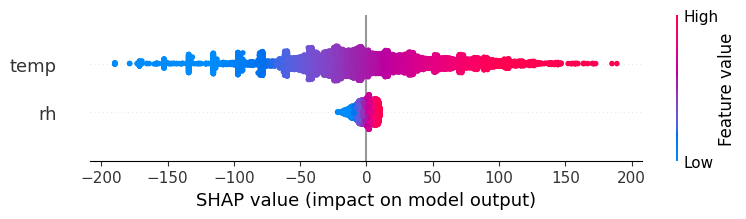

LIME and SHAP explanations generated.


In [ ]:
# Install necessary libraries if not already installed
!pip install lime shap scikit-learn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import lime
import lime.lime_tabular
import shap
import numpy as np

print("Libraries installed and imported successfully.")

# Load the extracted data
df = pd.read_csv("2024full.csv")

# Apply dropna as requested
df = df.dropna(subset=['temp', 'rh', 'wdLoad'])

# Features and target variable as specified by the user
X = df[['temp', 'rh']]
y = df['wdLoad']

print("Data loaded and preprocessed.")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Print the coefficients and intercept
print("\n--- Linear Regression Model ---")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient for temp: {model.coef_[0]:.4f}")
print(f"Coefficient for rh: {model.coef_[1]:.4f}")
print(f"Equation: wdLoad = {model.intercept_:.4f} + ({model.coef_[0]:.4f} * temp) + ({model.coef_[1]:.4f} * rh)")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error (MAE) on test set: {mae:.4f}")
print(f"R-squared (R2) on test set: {r2:.4f}")

# --- LIME Explanation ---
print("\n--- LIME Explanation (Local Interpretability) ---")
# Create a LIME explainer object
# Using feature names from X.columns and training data for background statistics
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['wdLoad'], # For regression, can be arbitrary, or predict a single value
    mode='regression'
)

# Choose a random instance from the test set to explain
np.random.seed(42) # for reproducibility
instance_idx = np.random.randint(0, len(X_test))
exp_instance = X_test.iloc[instance_idx].values

print(f"Explaining prediction for instance:\n{X_test.iloc[instance_idx]}")

# Explain the instance
explanation = explainer.explain_instance(
    data_row=exp_instance,
    predict_fn=model.predict,
    num_features=len(X.columns)
)

# Print the explanation (feature contributions)
print("Feature contributions for the selected instance:")
print(explanation.as_list())

# You can also visualize the explanation
explanation.show_in_notebook(show_table=True, show_all=False)

# --- SHAP Explanation ---
print("\n--- SHAP Explanation (Global and Local Interpretability) ---")

# Create a SHAP explainer for the linear model
# Using a small subset of the training data as background distribution for performance
explainer_shap = shap.LinearExplainer(model, X_train)

# Calculate SHAP values for the test set
shap_values = explainer_shap.shap_values(X_test)

# For a single instance (the same one used for LIME)
print(f"SHAP values for the same instance (index {instance_idx}):")
shap_values_instance = shap_values[instance_idx]
for feature, shap_val in zip(X.columns, shap_values_instance):
    print(f"{feature}: {shap_val:.4f}")

# SHAP summary plot (requires matplotlib, will output as image)
print("Generating SHAP summary plot (may take a moment)...")
shap.summary_plot(shap_values, X_test)

print("LIME and SHAP explanations generated.")

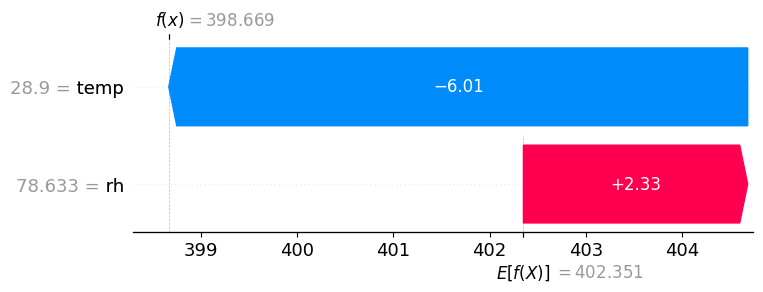

In [ ]:
shap.plots.waterfall(shap.Explanation(values=shap_values[0], base_values=explainer_shap.expected_value, data=X_test.iloc[0]))

In [ ]:
explanation.show_in_notebook(show_table=True, show_all=False)

Econml Equations

gpt code

In [ ]:
season_coefs = {
    'Winter': {'temp': 4.156472424110865, 'rh': 1.192767325239574},
    'Summer': {'temp': 11.9614910117417, 'rh': 1.335793191206736},
    'Monsoon': {'temp': 6.804644883188345, 'rh': -0.5082603464852803},
    'Autumn': {'temp': 6.705353137247921, 'rh': 0.8443274869794828}
}

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_season(file_path, season_name):

    df = pd.read_csv(file_path)
    df = df.sort_values('datetime').reset_index(drop=True)

    # Compute changes
    df['d_temp'] = df['temp'].diff()
    df['d_rh'] = df['rh'].diff()

    beta_temp = season_coefs[season_name]['temp']
    beta_rh = season_coefs[season_name]['rh']

    df['pred_load'] = np.nan

    # Apply equation
    for i in range(1, len(df)):
        df.loc[i, 'pred_load'] = (
            df.loc[i-1, 'wdLoad'] +
            beta_temp * df.loc[i, 'd_temp'] +
            beta_rh * df.loc[i, 'd_rh']
        )

    df = df.dropna()

    # Metrics
    rmse = np.sqrt(mean_squared_error(df['wdLoad'], df['pred_load']))
    mae = mean_absolute_error(df['wdLoad'], df['pred_load'])

    mape = np.mean(
        np.abs((df['wdLoad'] - df['pred_load']) / df['wdLoad'])
    ) * 100

    return rmse, mae, mape, df

In [ ]:
results = {}

files = {
    'Winter': 'winter_2025.csv',
    'Summer': 'summer_2025.csv',
    'Monsoon': 'monsoon_2025.csv',
    'Autumn': 'autumn_2025.csv'
}

for season, file in files.items():
    rmse, mae, mape, df_out = evaluate_season(file, season)

    results[season] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

In [ ]:
results_df = pd.DataFrame(results).T
print(results_df)

             RMSE       MAE      MAPE
Winter   6.050294  4.623667  1.234068
Summer   6.240535  4.654135  1.060194
Monsoon  6.807567  5.175392  1.198509
Autumn   6.254854  4.830371  1.140678


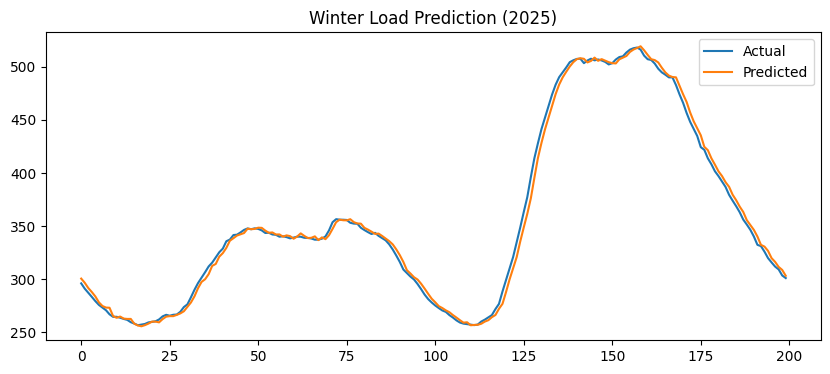

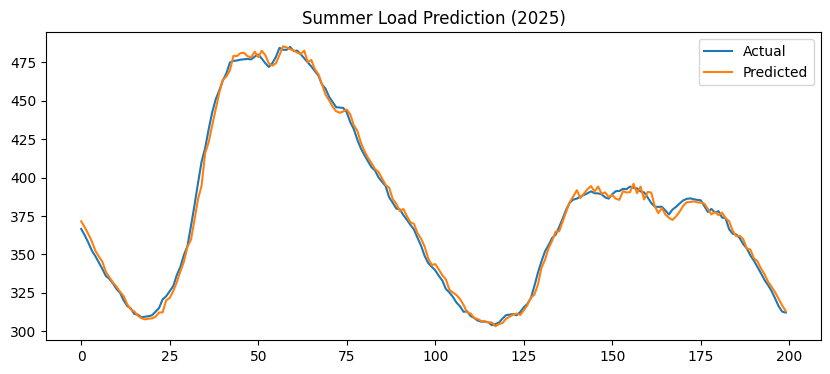

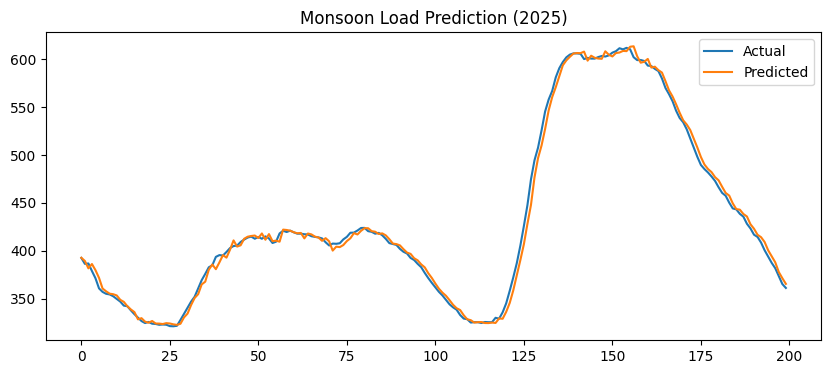

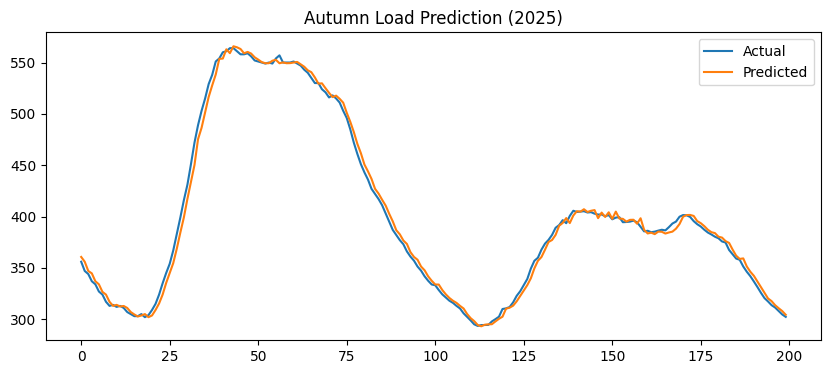

In [ ]:
import matplotlib.pyplot as plt

for season, file in files.items():

    _, _, _, df_plot = evaluate_season(file, season)

    plt.figure(figsize=(10,4))
    plt.plot(df_plot['wdLoad'].values[:200], label='Actual')
    plt.plot(df_plot['pred_load'].values[:200], label='Predicted')

    plt.title(f"{season} Load Prediction (2025)")
    plt.legend()
    plt.show()

Gemini code

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def evaluate_season(file_path, beta_temp, beta_rh):
    df = pd.read_csv('./winter_2025.csv')


    # Calculate differences (Current - Previous)
    df['diff_temp'] = df['temp'].diff()
    df['diff_rh'] = df['rh'].diff()

    # Predict: Actual_(t-1) + (coeff * diff)
    # We shift the actual load to get Y_{t-1}
    df['predicted_load'] = df['wdLoad'].shift(1) + \
                           (beta_temp * df['diff_temp']) + \
                           (beta_rh * df['diff_rh'])

    # Drop first row as it won't have a prediction (no t-1)
    df_eval = df.dropna(subset=['predicted_load'])

    y_true = df_eval['wdLoad']
    y_pred = df_eval['predicted_load']

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

# Example call for Winter 2025
winter_results = evaluate_season('winter_2025.csv', 4.15647, 1.19277)
print(f"Winter Results: {winter_results}")

Winter Results: {'MAE': 4.623668217686691, 'RMSE': np.float64(6.050295530382929), 'MAPE': 1.2340688456941638}


Claude code

In [ ]:
# ============================================================
#  EconML ATE-Based Load Prediction — Google Colab Script
#  Data: 15-min interval, columns: datetime, wdLoad, temp, rh, year, month
#  Equation: Ŷ_t = Y_{t-1} + β_temp·ΔTemp + β_rh·ΔRH
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── ATE Coefficients (from EconML) ───────────────────────────
ATE = {
    "winter":  {"temp": 4.156472424110865,   "rh":  1.192767325239574},
    "summer":  {"temp": 11.9614910117417,    "rh":  1.335793191206736},
    "monsoon": {"temp": 6.804644883188345,   "rh": -0.5082603464852803},
    "autumn":  {"temp": 6.705353137247921,   "rh":  0.8443274869794828},
}

# ── File paths — update DATA_DIR if needed ───────────────────
DATA_DIR = "/content/"

FILE_MAP = {
    "winter":  "winter_2025.csv",
    "summer":  "summer_2025.csv",
    "monsoon": "monsoon_2025.csv",
    "autumn":  "autumn_2025.csv",
}

# ── Column names (fixed based on your data) ──────────────────
COL_LOAD = "wdLoad"
COL_TEMP = "temp"
COL_RH   = "rh"
COL_DT   = "datetime"

# ── Helper: predict ───────────────────────────────────────────
def predict_load(df, coeff_temp, coeff_rh):
    df = df.copy().reset_index(drop=True)

    df["delta_temp"]     = df[COL_TEMP].diff()          # Temp_t - Temp_{t-1}
    df["delta_rh"]       = df[COL_RH].diff()            # RH_t   - RH_{t-1}
    df["prev_load"]      = df[COL_LOAD].shift(1)        # Y_{t-1} actual

    df["predicted_load"] = (
        df["prev_load"]
        + coeff_temp * df["delta_temp"]
        + coeff_rh   * df["delta_rh"]
    )

    # Drop first row (no previous tuple)
    df = df.dropna(subset=["predicted_load"]).reset_index(drop=True)
    return df

# ── Helper: metrics ───────────────────────────────────────────
def compute_metrics(actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

# ── Main ──────────────────────────────────────────────────────
summary_rows = []

for season, filename in FILE_MAP.items():
    filepath = DATA_DIR + filename
    try:
        df = pd.read_csv(filepath, parse_dates=[COL_DT])
    except FileNotFoundError:
        print(f"⚠️  [{season.upper()}] Not found: {filepath} — skipping.\n")
        continue

    # Sort by datetime to ensure correct time order
    df = df.sort_values(COL_DT).reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"  Season   : {season.upper()}")
    print(f"  File     : {filename}")
    print(f"  Shape    : {df.shape}  |  Rows = {len(df)}  (~{len(df)//96} days @ 15-min)")
    print(f"  Period   : {df[COL_DT].iloc[0]}  →  {df[COL_DT].iloc[-1]}")
    print(f"  Load range : {df[COL_LOAD].min():.1f} – {df[COL_LOAD].max():.1f} MW")
    print(f"  Temp range : {df[COL_TEMP].min():.1f} – {df[COL_TEMP].max():.1f} °C")
    print(f"  RH range   : {df[COL_RH].min():.1f}  – {df[COL_RH].max():.1f}  %")

    coeff_temp = ATE[season]["temp"]
    coeff_rh   = ATE[season]["rh"]

    result_df = predict_load(df, coeff_temp, coeff_rh)

    mae, rmse, mape = compute_metrics(result_df[COL_LOAD], result_df["predicted_load"])

    print(f"\n  Equation : Ŷ_t = Y_{{t-1}} + {coeff_temp:.4f}·ΔTemp + ({coeff_rh:.4f})·ΔRH")
    print(f"  Samples  : {len(result_df)}")
    print(f"  ┌───────────────────────┐")
    print(f"  │ MAE      : {mae:>10.4f} │")
    print(f"  │ RMSE     : {rmse:>10.4f} │")
    print(f"  │ MAPE (%) : {mape:>10.4f} │")
    print(f"  └───────────────────────┘")

    out_path = DATA_DIR + f"{season}_2025_predictions.csv"
    result_df[[COL_DT, COL_LOAD, COL_TEMP, COL_RH,
               "prev_load", "delta_temp", "delta_rh",
               "predicted_load"]].to_csv(out_path, index=False)
    print(f"  ✅ Saved: {out_path}")

    summary_rows.append({
        "Season":   season.capitalize(),
        "β_temp":   coeff_temp,
        "β_rh":     coeff_rh,
        "Samples":  len(result_df),
        "MAE":      round(mae,  4),
        "RMSE":     round(rmse, 4),
        "MAPE (%)": round(mape, 4),
    })

# ── Summary ───────────────────────────────────────────────────
if summary_rows:
    print(f"\n{'='*60}")
    print("  SUMMARY — All Seasons")
    print(f"{'='*60}")
    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))

    summary_path = DATA_DIR + "season_metrics_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    print(f"\n✅ Summary saved: {summary_path}")


  Season   : WINTER
  File     : winter_2025.csv
  Shape    : (8640, 6)  |  Rows = 8640  (~90 days @ 15-min)
  Period   : 2024-12-01 00:00:00+05:30  →  2025-02-28 23:45:00+05:30
  Load range : 249.9 – 570.5 MW
  Temp range : 20.5 – 37.2 °C
  RH range   : 20.4  – 86.7  %

  Equation : Ŷ_t = Y_{t-1} + 4.1565·ΔTemp + (1.1928)·ΔRH
  Samples  : 8639
  ┌───────────────────────┐
  │ MAE      :     4.6237 │
  │ RMSE     :     6.0503 │
  │ MAPE (%) :     1.2341 │
  └───────────────────────┘
  ✅ Saved: /content/winter_2025_predictions.csv

  Season   : SUMMER
  File     : summer_2025.csv
  Shape    : (8832, 6)  |  Rows = 8832  (~92 days @ 15-min)
  Period   : 2025-03-01 00:00:00+05:30  →  2025-05-31 23:45:00+05:30
  Load range : 292.0 – 639.8 MW
  Temp range : 23.5 – 38.0 °C
  RH range   : 22.4  – 97.6  %

  Equation : Ŷ_t = Y_{t-1} + 11.9615·ΔTemp + (1.3358)·ΔRH
  Samples  : 8831
  ┌───────────────────────┐
  │ MAE      :     4.6541 │
  │ RMSE     :     6.2405 │
  │ MAPE (%) :     1.0602 │
  └

Plot

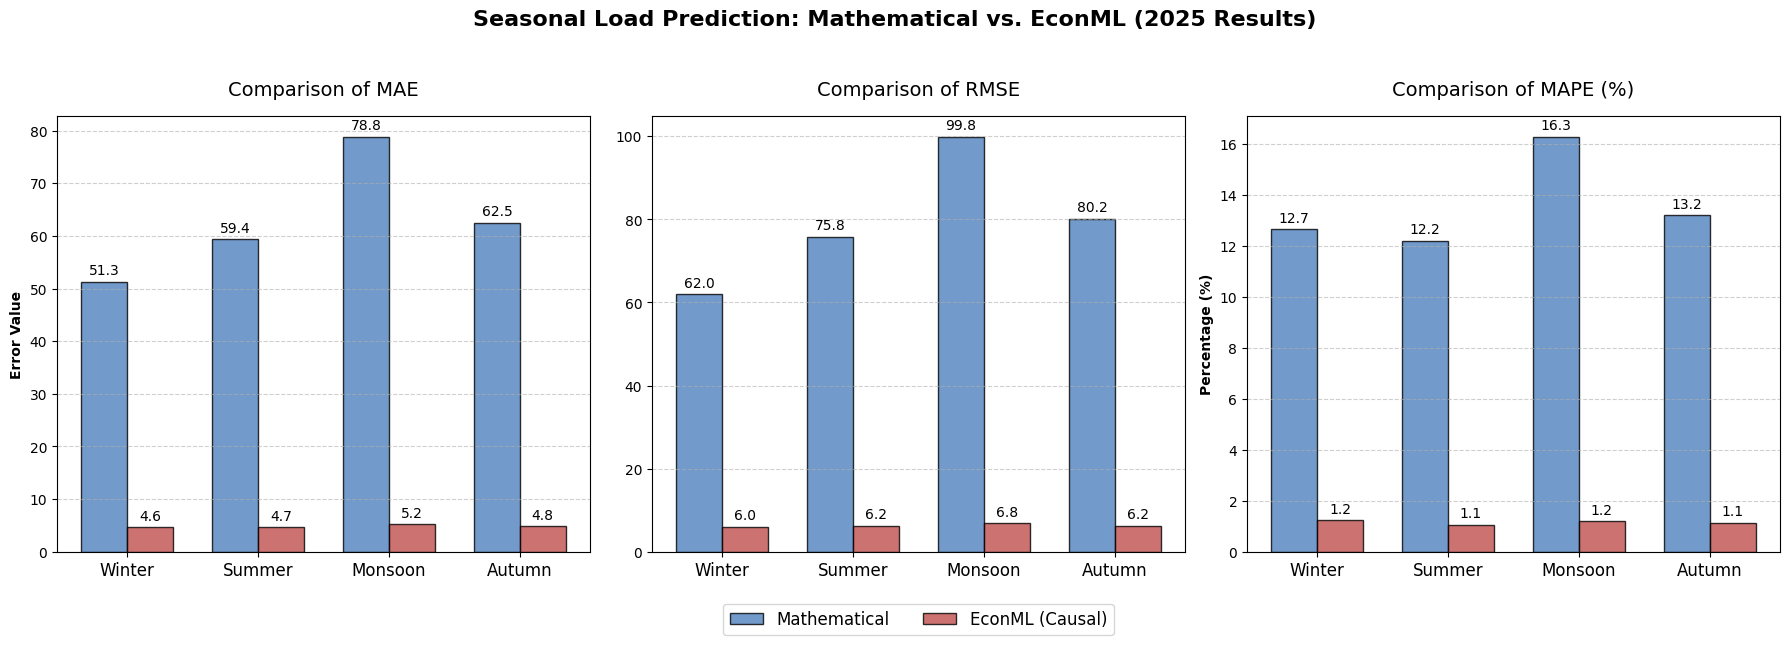

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
seasons = ['Winter', 'Summer', 'Monsoon', 'Autumn']
metrics = ['MAE', 'RMSE', 'MAPE (%)']

# Mathematical Approach Data
math_mae = [51.30, 59.37, 78.79, 62.52]
math_rmse = [62.01, 75.82, 99.84, 80.18]
math_mape = [12.66, 12.21, 16.29, 13.21]

# EconML Approach Data
econ_mae = [4.62, 4.65, 5.18, 4.83]
econ_rmse = [6.05, 6.24, 6.81, 6.25]
econ_mape = [1.23, 1.06, 1.20, 1.14]

math_all = [math_mae, math_rmse, math_mape]
econ_all = [econ_mae, econ_rmse, econ_mape]

# Create Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True)
fig.suptitle('Seasonal Load Prediction: Mathematical vs. EconML (2025 Results)', fontsize=16, fontweight='bold')

x = np.arange(len(seasons))
width = 0.35

for i, ax in enumerate(axes):
    # Plot Bars
    b1 = ax.bar(x - width/2, math_all[i], width, label='Mathematical', color='#4F81BD', edgecolor='black', alpha=0.8)
    b2 = ax.bar(x + width/2, econ_all[i], width, label='EconML (Causal)', color='#C0504D', edgecolor='black', alpha=0.8)

    # Title and Labels
    ax.set_title(f'Comparison of {metrics[i]}', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(seasons, fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Add Value Labels
    for bar in b1 + b2:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

axes[0].set_ylabel('Error Value', fontweight='bold')
axes[2].set_ylabel('Percentage (%)', fontweight='bold')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('all_metrics_comparison.png', dpi=300)

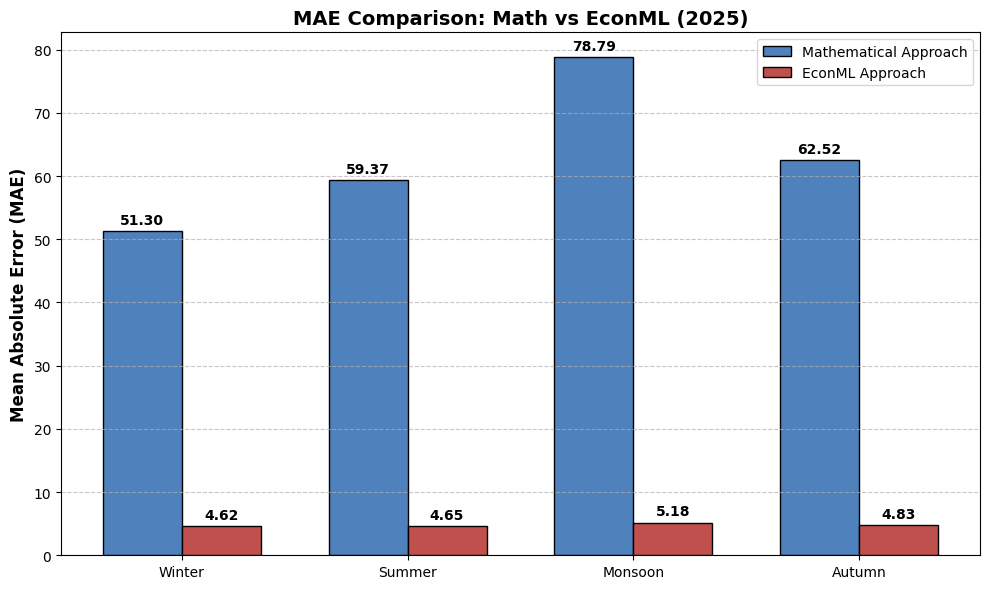

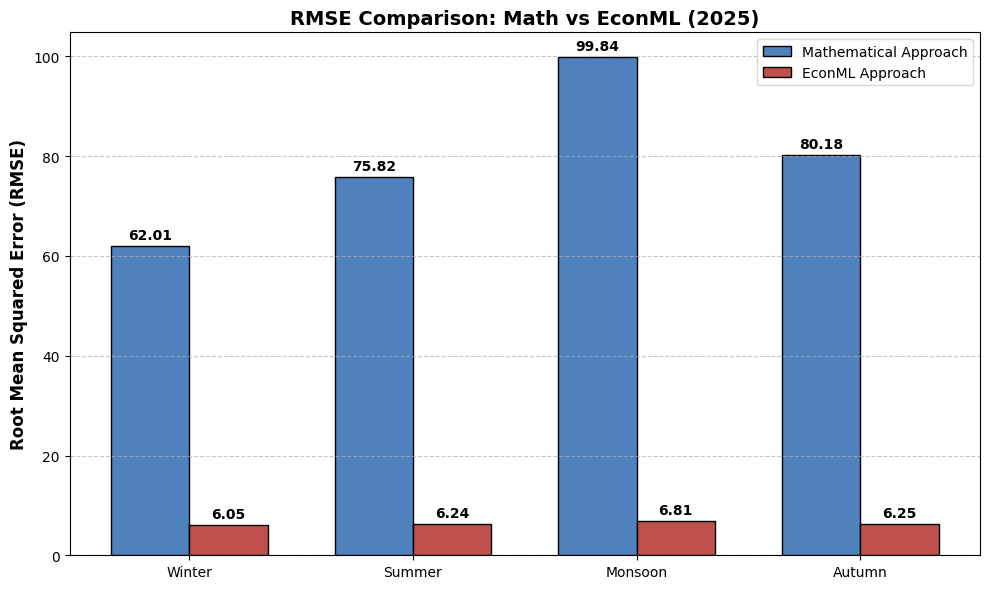

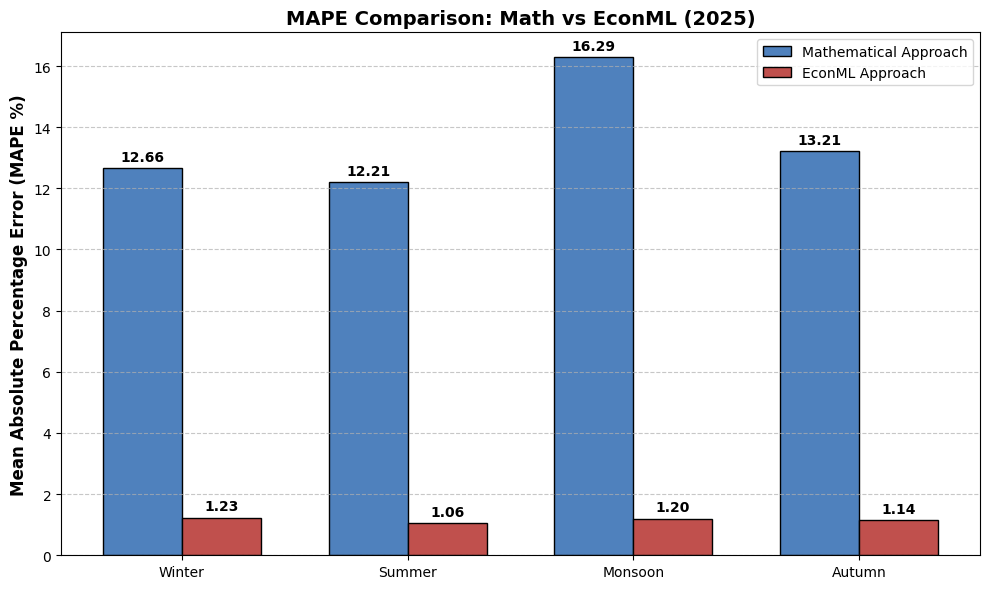

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation
seasons = ['Winter', 'Summer', 'Monsoon', 'Autumn']

# Mathematical Approach Results
math_mae = [51.2980, 59.3710, 78.7931, 62.5210]
math_rmse = [62.0100, 75.8168, 99.8375, 80.1818]
math_mape = [12.6578, 12.2102, 16.2874, 13.2134]

# EconML Approach Results
econ_mae = [4.623667, 4.654135, 5.175392, 4.830371]
econ_rmse = [6.050294, 6.240535, 6.807567, 6.254854]
econ_mape = [1.234068, 1.060194, 1.198509, 1.140678]

# Helper function to add data labels on top of bars
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plotting Parameters
x = np.arange(len(seasons))  # Label locations
width = 0.35  # Width of the bars

# --- PLOT 1: MAE COMPARISON ---
plt.figure(figsize=(10, 6))
rects1 = plt.bar(x - width/2, math_mae, width, label='Mathematical Approach', color='#4F81BD', edgecolor='black')
rects2 = plt.bar(x + width/2, econ_mae, width, label='EconML Approach', color='#C0504D', edgecolor='black')

plt.ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
plt.title('MAE Comparison: Math vs EconML (2025)', fontsize=14, fontweight='bold')
plt.xticks(x, seasons)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
autolabel(rects1, plt.gca())
autolabel(rects2, plt.gca())
plt.tight_layout()
plt.savefig('mae_comparison.png', dpi=300)
plt.show()

# --- PLOT 2: RMSE COMPARISON ---
plt.figure(figsize=(10, 6))
rects1 = plt.bar(x - width/2, math_rmse, width, label='Mathematical Approach', color='#4F81BD', edgecolor='black')
rects2 = plt.bar(x + width/2, econ_rmse, width, label='EconML Approach', color='#C0504D', edgecolor='black')

plt.ylabel('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
plt.title('RMSE Comparison: Math vs EconML (2025)', fontsize=14, fontweight='bold')
plt.xticks(x, seasons)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
autolabel(rects1, plt.gca())
autolabel(rects2, plt.gca())
plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=300)
plt.show()

# --- PLOT 3: MAPE COMPARISON ---
plt.figure(figsize=(10, 6))
rects1 = plt.bar(x - width/2, math_mape, width, label='Mathematical Approach', color='#4F81BD', edgecolor='black')
rects2 = plt.bar(x + width/2, econ_mape, width, label='EconML Approach', color='#C0504D', edgecolor='black')

plt.ylabel('Mean Absolute Percentage Error (MAPE %)', fontsize=12, fontweight='bold')
plt.title('MAPE Comparison: Math vs EconML (2025)', fontsize=14, fontweight='bold')
plt.xticks(x, seasons)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
autolabel(rects1, plt.gca())
autolabel(rects2, plt.gca())
plt.tight_layout()
plt.savefig('mape_comparison.png', dpi=300)
plt.show()